# 🧠 Visualize What/Where Dual-Stream Hypothesis

## Mục tiêu
Chứng minh rằng kiến trúc Dual-Stream của ChasmBrain hoạt động như thiết kế:

| Branch | Input | Kỳ vọng predict tốt hơn ở vùng não |
|--------|-------|------------------------------------|
| **What** | CLS Token | Ventral stream (Object Identity) |
| **Where** | Patch Tokens | Dorsal stream (Spatial Details) |

## Phương pháp
1. Chạy model, lấy `what_roi` và `where_roi` **TRƯỚC** fusion
2. Load Ground Truth fMRI
3. Tính **correlation** của mỗi branch với GT
4. So sánh: Branch nào predict **đúng hơn** cho mỗi vùng não?

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries loaded!")

Libraries loaded!


## 1. Load Brain Atlas (ROI Mapping)

In [2]:
# Load ROI mapping
roi_mapping = np.load('../dataset/nsd/metadata/subj01_roi_mapping.npz')
with open('../dataset/nsd/metadata/roi_labels.json', 'r') as f:
    roi_labels = json.load(f)

# Stream mapping (có data đầy đủ hơn visual ROIs)
streams = roi_mapping['streams']  # shape: (15724,)
stream_to_voxels = {}
for stream_id, stream_name in roi_labels['streams'].items():
    stream_id = int(stream_id)
    voxel_indices = np.where(streams == stream_id)[0]
    stream_to_voxels[stream_name] = voxel_indices

print("Streams:")
for name, indices in stream_to_voxels.items():
    print(f"  {name}: {len(indices)} voxels")

Streams:
  Early: 5463 voxels
  Midventral: 986 voxels
  Midlateral: 834 voxels
  Lateral: 856 voxels
  Ventral: 3630 voxels
  Parietal: 2375 voxels


In [3]:
# Định nghĩa What/Where streams theo neuroscience
# WHAT (Ventral Stream): nhận diện object
# WHERE (Dorsal Stream): xử lý spatial

WHAT_STREAMS = ['Lateral', 'Ventral', 'Midventral']  # Object identity
WHERE_STREAMS = ['Early', 'Midlateral', 'Parietal']   # Spatial details

print("WHAT streams (Ventral - Object Identity):")
for s in WHAT_STREAMS:
    print(f"  {s}: {len(stream_to_voxels.get(s, []))} voxels")

print("\nWHERE streams (Dorsal - Spatial Details):")
for s in WHERE_STREAMS:
    print(f"  {s}: {len(stream_to_voxels.get(s, []))} voxels")

WHAT streams (Ventral - Object Identity):
  Lateral: 856 voxels
  Ventral: 3630 voxels
  Midventral: 986 voxels

WHERE streams (Dorsal - Spatial Details):
  Early: 5463 voxels
  Midlateral: 834 voxels
  Parietal: 2375 voxels


## 2. Load Model

In [4]:
from model.hierarchical_v3 import HierarchicalARM_V3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = HierarchicalARM_V3(
    cls_dim=768,
    patch_dim=768,
    num_patches=256,
    fmri_dim=15724,
    voxels_per_cluster=30,
).to(device)

# TODO: Load checkpoint nếu có
# checkpoint = torch.load('../checkpoints/your_checkpoint.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Num ROIs: {model.num_rois}")

Using device: cuda
DualStreamMambaStage1: 15724 voxels → 524 ROIs (30 voxels/ROI, 4 remainder)
Model parameters: 287,843,719
Num ROIs: 524


In [5]:
def extract_what_where(model, cls_token, patch_tokens):
    """
    Extract what_roi và where_roi TRƯỚC fusion.
    """
    stage1 = model.stage1
    
    # What Branch
    what_x = stage1.what_proj(cls_token).unsqueeze(1)
    what_x = stage1.what_norm(what_x)
    with torch.amp.autocast('cuda', enabled=False):
        what_x_fp32 = what_x.float()
        for mamba in stage1.what_mamba:
            residual = torch.clamp(mamba(what_x_fp32), -10, 10)
            what_x_fp32 = what_x_fp32 + residual
        what_x = what_x_fp32.to(what_x.dtype)
    what_feat = what_x.squeeze(1)
    what_roi = stage1.what_head(what_feat)
    
    # Where Branch
    where_x = stage1.where_proj(patch_tokens)
    where_x = where_x + stage1.where_pos_embed
    where_x = stage1.where_norm(where_x)
    with torch.amp.autocast('cuda', enabled=False):
        where_x_fp32 = where_x.float()
        for mamba in stage1.where_mamba:
            residual = torch.clamp(mamba(where_x_fp32), -10, 10)
            where_x_fp32 = where_x_fp32 + residual
        where_x = where_x_fp32.to(where_x.dtype)
    where_pooled = stage1.where_pool(where_x.mean(dim=1))
    where_roi = stage1.where_head(where_pooled)
    
    return what_roi, where_roi

print("extract_what_where function defined!")

extract_what_where function defined!


## 3. Load Data và Chạy Inference

In [6]:
# Load test data
cls_test = np.load('../dataset/nsd/embeddings_mindeye2/dinov2_test_sub01.npy')
patches_test_raw = np.load('../dataset/nsd/embeddings_patches/dinov2_patches_test_sub01.npy')
patches_test = patches_test_raw[:, 1:, :]  # Bỏ CLS token, giữ 256 patches

# Load Ground Truth fMRI
gt_fmri = np.load('../dataset/nsd/mixed_1000_sub01/test_fmri.npy')

print(f"CLS tokens: {cls_test.shape}")
print(f"Patch tokens: {patches_test.shape}")
print(f"GT fMRI: {gt_fmri.shape}")

CLS tokens: (982, 768)
Patch tokens: (982, 256, 768)
GT fMRI: (982, 15724)


In [7]:
# Chạy inference
num_samples = min(100, len(cls_test))
batch_size = 16

all_what_roi = []
all_where_roi = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size):
        end_idx = min(i + batch_size, num_samples)
        
        cls_batch = torch.tensor(cls_test[i:end_idx]).to(device)
        patches_batch = torch.tensor(patches_test[i:end_idx]).to(device)
        
        what_roi, where_roi = extract_what_where(model, cls_batch, patches_batch)
        
        all_what_roi.append(what_roi.cpu().numpy())
        all_where_roi.append(where_roi.cpu().numpy())

all_what_roi = np.concatenate(all_what_roi, axis=0)  # [N, 524]
all_where_roi = np.concatenate(all_where_roi, axis=0)  # [N, 524]

print(f"what_roi: {all_what_roi.shape}")
print(f"where_roi: {all_where_roi.shape}")

what_roi: (100, 524)
where_roi: (100, 524)


In [8]:
# Tính GT ROI means
voxels_per_cluster = model.voxels_per_cluster  # 30
num_rois = model.num_rois  # 524

gt_fmri_subset = gt_fmri[:num_samples]
gt_roi_means = np.zeros((num_samples, num_rois))

for roi_idx in range(num_rois):
    start_voxel = roi_idx * voxels_per_cluster
    end_voxel = start_voxel + voxels_per_cluster
    gt_roi_means[:, roi_idx] = gt_fmri_subset[:, start_voxel:end_voxel].mean(axis=1)

print(f"GT ROI means: {gt_roi_means.shape}")

GT ROI means: (100, 524)


## 4. Tính Correlation với Ground Truth

**Key insight:**
- `corr_diff = What_correlation - Where_correlation`
- `corr_diff > 0` → What branch predict **đúng hơn**
- `corr_diff < 0` → Where branch predict **đúng hơn**

In [9]:
def compute_correlation_per_roi(pred, gt):
    """Tính Pearson correlation cho mỗi ROI."""
    num_rois = pred.shape[1]
    correlations = np.zeros(num_rois)
    
    for roi_idx in range(num_rois):
        corr, _ = pearsonr(pred[:, roi_idx], gt[:, roi_idx])
        correlations[roi_idx] = corr if not np.isnan(corr) else 0
    
    return correlations

# Tính correlation cho mỗi branch
what_corr = compute_correlation_per_roi(all_what_roi, gt_roi_means)
where_corr = compute_correlation_per_roi(all_where_roi, gt_roi_means)

# Correlation difference: positive = What better, negative = Where better
corr_diff = what_corr - where_corr

print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)
print(f"What correlation:  mean={what_corr.mean():.4f}, range=[{what_corr.min():.4f}, {what_corr.max():.4f}]")
print(f"Where correlation: mean={where_corr.mean():.4f}, range=[{where_corr.min():.4f}, {where_corr.max():.4f}]")
print(f"\nCorr diff (What - Where): range=[{corr_diff.min():.4f}, {corr_diff.max():.4f}]")
print(f"ROIs where What better: {(corr_diff > 0).sum()} / {len(corr_diff)}")
print(f"ROIs where Where better: {(corr_diff < 0).sum()} / {len(corr_diff)}")

CORRELATION ANALYSIS
What correlation:  mean=0.0031, range=[-0.2917, 0.2508]
Where correlation: mean=-0.0078, range=[-0.2894, 0.2555]

Corr diff (What - Where): range=[-0.3834, 0.3905]
ROIs where What better: 265 / 524
ROIs where Where better: 259 / 524


## 5. Visualization

/tmp/ipykernel_3381746/2203362357.py:23: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3381746/2203362357.py:23: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3381746/2203362357.py:24: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig('../docs/what_where_correlation_distribution.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3381746/2203362357.py:24: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig('../docs/what_where_correlation_distribution.png', dpi=150, bbox_inches='tight')
/home/sowwn/Workspace/ws/2026/I2fMRI/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sowwn/Workspace

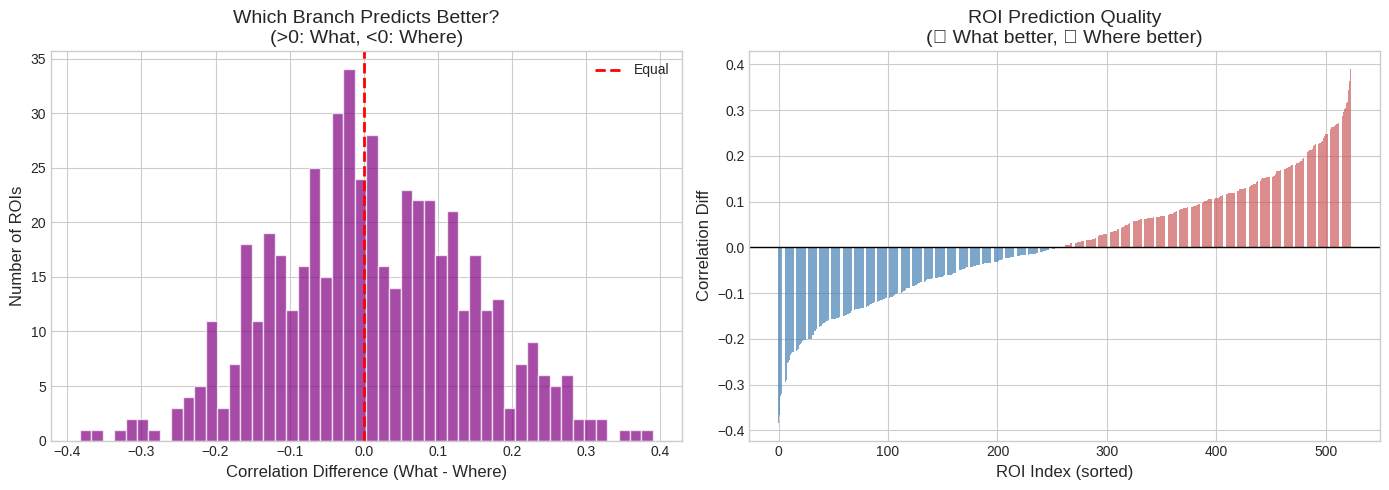

In [10]:
# Visualization 1: Distribution of correlation difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(corr_diff, bins=50, color='purple', edgecolor='white', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Equal')
ax1.set_xlabel('Correlation Difference (What - Where)', fontsize=12)
ax1.set_ylabel('Number of ROIs', fontsize=12)
ax1.set_title('Which Branch Predicts Better?\n(>0: What, <0: Where)', fontsize=14)
ax1.legend()

# Sorted bar chart
ax2 = axes[1]
sorted_idx = np.argsort(corr_diff)
colors = ['steelblue' if x < 0 else 'indianred' for x in corr_diff[sorted_idx]]
ax2.bar(range(len(corr_diff)), corr_diff[sorted_idx], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('ROI Index (sorted)', fontsize=12)
ax2.set_ylabel('Correlation Diff', fontsize=12)
ax2.set_title('ROI Prediction Quality\n(🔴 What better, 🔵 Where better)', fontsize=14)

plt.tight_layout()
plt.savefig('../docs/what_where_correlation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Expand ROI-level → Voxel-level
voxel_corr_diff = np.zeros(15724)
for roi_idx in range(num_rois):
    start_voxel = roi_idx * voxels_per_cluster
    end_voxel = start_voxel + voxels_per_cluster
    voxel_corr_diff[start_voxel:end_voxel] = corr_diff[roi_idx]

print(f"Voxel-level corr_diff: {voxel_corr_diff.shape}")

Voxel-level corr_diff: (15724,)


In [12]:
# Tính mean correlation diff cho mỗi Stream
stream_corr_diff = {}

print("="*60)
print("WHAT STREAMS (Kỳ vọng: What predict tốt hơn → value > 0)")
print("="*60)
for stream in WHAT_STREAMS:
    voxels = stream_to_voxels[stream]
    mean_diff = voxel_corr_diff[voxels].mean()
    stream_corr_diff[stream] = mean_diff
    status = "✓ What better" if mean_diff > 0 else "✗ Where better"
    print(f"  {stream:12s}: {mean_diff:+.4f} {status}")

print("\n" + "="*60)
print("WHERE STREAMS (Kỳ vọng: Where predict tốt hơn → value < 0)")
print("="*60)
for stream in WHERE_STREAMS:
    voxels = stream_to_voxels[stream]
    mean_diff = voxel_corr_diff[voxels].mean()
    stream_corr_diff[stream] = mean_diff
    status = "✗ What better" if mean_diff > 0 else "✓ Where better"
    print(f"  {stream:12s}: {mean_diff:+.4f} {status}")

WHAT STREAMS (Kỳ vọng: What predict tốt hơn → value > 0)
  Lateral     : +0.0306 ✓ What better
  Ventral     : -0.0033 ✗ Where better
  Midventral  : +0.0387 ✓ What better

WHERE STREAMS (Kỳ vọng: Where predict tốt hơn → value < 0)
  Early       : +0.0143 ✗ What better
  Midlateral  : +0.0233 ✗ What better
  Parietal    : +0.0035 ✗ What better


/tmp/ipykernel_3381746/1360729067.py:31: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3381746/1360729067.py:31: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3381746/1360729067.py:32: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig('../docs/what_where_streams_correlation.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3381746/1360729067.py:32: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig('../docs/what_where_streams_correlation.png', dpi=150, bbox_inches='tight')
/home/sowwn/Workspace/ws/2026/I2fMRI/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sowwn/Workspace/ws/2026/I

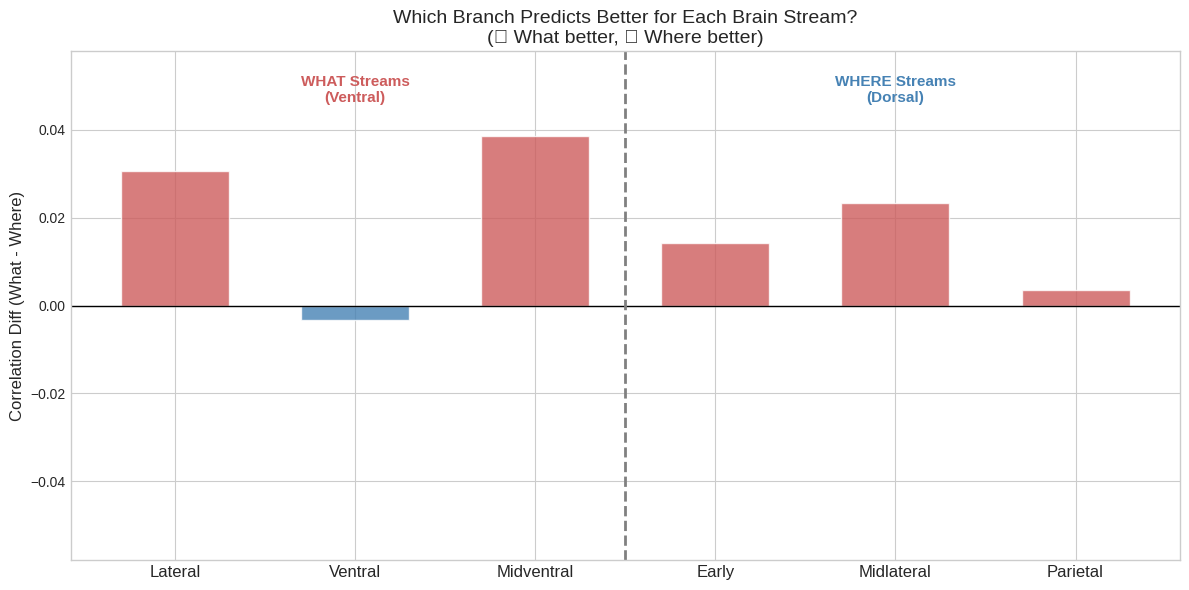

In [15]:
# Bar chart: Stream-level analysis
fig, ax = plt.subplots(figsize=(12, 6))

what_data = [(s, stream_corr_diff[s]) for s in WHAT_STREAMS]
where_data = [(s, stream_corr_diff[s]) for s in WHERE_STREAMS]
all_data = what_data + where_data

names = [d[0] for d in all_data]
values = [d[1] for d in all_data]
colors = ['indianred' if v > 0 else 'steelblue' for v in values]

separator_idx = len(what_data)

bars = ax.bar(range(len(names)), values, color=colors, edgecolor='white', alpha=0.8, width=0.6)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=separator_idx - 0.5, color='gray', linestyle='--', linewidth=2)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel('Correlation Diff (What - Where)', fontsize=12)
ax.set_title('Which Branch Predicts Better for Each Brain Stream?\n'
             '(🔴 What better, 🔵 Where better)', fontsize=14)

y_max = max(abs(min(values)), abs(max(values))) * 1.5
ax.set_ylim(-y_max, y_max)
ax.text(separator_idx/2 - 0.5, y_max*0.8, 'WHAT Streams\n(Ventral)', 
        ha='center', fontsize=11, fontweight='bold', color='indianred')
ax.text(separator_idx + 1, y_max*0.8, 'WHERE Streams\n(Dorsal)', 
        ha='center', fontsize=11, fontweight='bold', color='steelblue')

plt.tight_layout()
plt.savefig('../docs/what_where_streams_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [16]:
# Summary
what_correct = sum(1 for s in WHAT_STREAMS if stream_corr_diff[s] > 0)
where_correct = sum(1 for s in WHERE_STREAMS if stream_corr_diff[s] < 0)

print("="*60)
print("SUMMARY: What/Where Hypothesis Validation")
print("="*60)

print(f"\n📊 WHAT Streams (should have What predict better → value > 0):")
for s in WHAT_STREAMS:
    status = "✓" if stream_corr_diff[s] > 0 else "✗"
    print(f"   {status} {s}: {stream_corr_diff[s]:+.4f}")
print(f"   Correct: {what_correct}/{len(WHAT_STREAMS)}")

print(f"\n📊 WHERE Streams (should have Where predict better → value < 0):")
for s in WHERE_STREAMS:
    status = "✓" if stream_corr_diff[s] < 0 else "✗"
    print(f"   {status} {s}: {stream_corr_diff[s]:+.4f}")
print(f"   Correct: {where_correct}/{len(WHERE_STREAMS)}")

total_correct = what_correct + where_correct
total = len(WHAT_STREAMS) + len(WHERE_STREAMS)
accuracy = 100 * total_correct / total

print(f"\n📊 Overall: {total_correct}/{total} ({accuracy:.1f}%)")

print("\n" + "="*60)
if accuracy >= 70:
    print("✅ HYPOTHESIS STRONGLY SUPPORTED!")
elif accuracy >= 50:
    print("⚠️ PARTIAL SUPPORT")
else:
    print("❌ HYPOTHESIS NOT SUPPORTED (Random weights?)")
print("="*60)

print("\n⚠️ NOTE: Results meaningful only with TRAINED model!")

SUMMARY: What/Where Hypothesis Validation

📊 WHAT Streams (should have What predict better → value > 0):
   ✓ Lateral: +0.0306
   ✗ Ventral: -0.0033
   ✓ Midventral: +0.0387
   Correct: 2/3

📊 WHERE Streams (should have Where predict better → value < 0):
   ✗ Early: +0.0143
   ✗ Midlateral: +0.0233
   ✗ Parietal: +0.0035
   Correct: 0/3

📊 Overall: 2/6 (33.3%)

❌ HYPOTHESIS NOT SUPPORTED (Random weights?)

⚠️ NOTE: Results meaningful only with TRAINED model!
